### Dataset

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import numpy as np
from torchvision.transforms.v2 import RandAugment
import torch
from tqdm.auto import tqdm
from torch.utils.tensorboard import SummaryWriter
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../models"))

from dataset import get_data_loaders
from backbone import BackBone
from metrics import SupConLoss
from utils import deterministic, backbone_train

/home/alumno1/miniconda3/envs/vision/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SEED = 42

In [4]:
deterministic(SEED)
dataloaders = get_data_loaders(batch_size=512)

/home/alumno1/miniconda3/envs/vision/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Task [0, 1]: Train=9000, Val=1000, Test=2000
Task [2, 3]: Train=9000, Val=1000, Test=2000
Task [4, 5]: Train=9000, Val=1000, Test=2000
Task [6, 7]: Train=9000, Val=1000, Test=2000
Task [8, 9]: Train=9000, Val=1000, Test=2000


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
backbone = BackBone().to(device)
optimizer = torch.optim.Adam(backbone.parameters(), lr=1e-2)
criterion = SupConLoss(tau=0.5)
tsne = TSNE(n_components=2, random_state=SEED)

/home/alumno1/miniconda3/envs/vision/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/alumno1/miniconda3/envs/vision/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epochs:   0%|          | 0/50 [00:00<?, ?epoch/s]

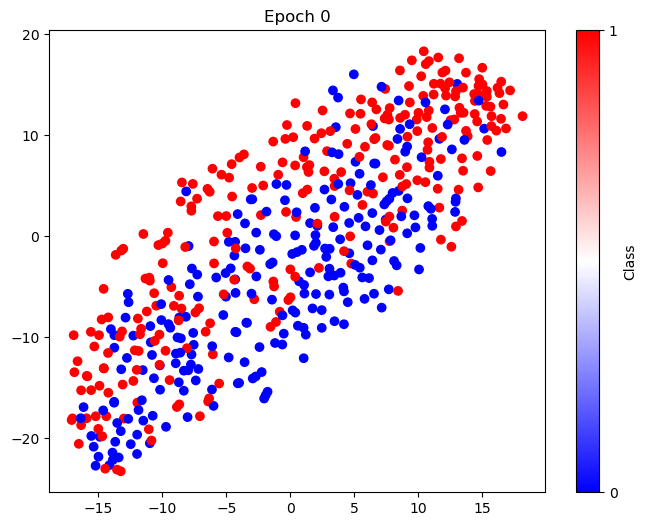

Epochs:  50%|█████     | 25/50 [00:34<00:32,  1.29s/epoch, loss=5.06]

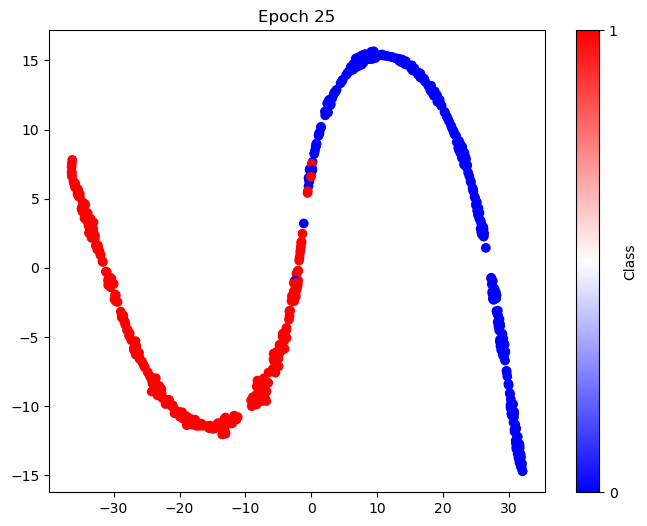

Epochs:  98%|█████████▊| 49/50 [01:06<00:01,  1.30s/epoch, loss=5.01]

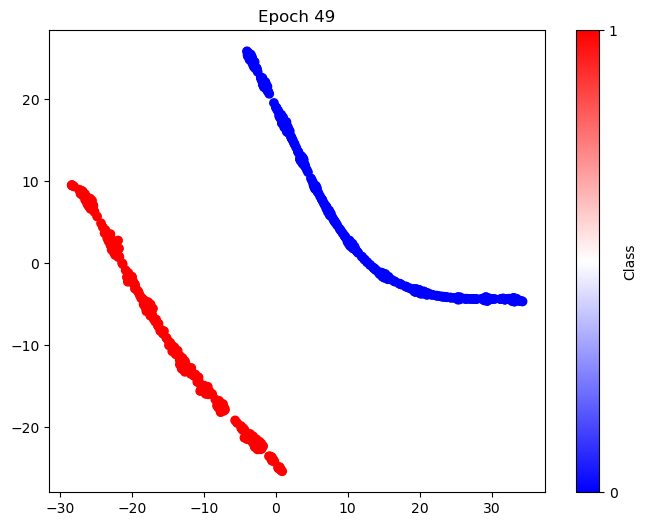

Epochs: 100%|██████████| 50/50 [01:09<00:00,  1.38s/epoch, loss=5.04]


In [6]:
deterministic(SEED)
task0_train = dataloaders[0][0]
rand_augment = RandAugment(num_ops=2, magnitude=9) # Hay que poner seed de vuelta?

epochs = 50

backbone_train(backbone, dataloaders[0][0], optimizer, criterion, "backbone", tsne, epochs)

In [7]:
# hacer gráfico de pérdida en preentrenamiento